# Phase 1: Single-Day Foundation

Validate data loading and feature engineering on one slate

Steps:
1. Load single slate raw data
2. Load historical player logs for training
3. Engineer features using transformers
4. Train single model (one player)
5. Generate prediction and calculate MAPE

## 1. Configuration

In [14]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from src.data.loaders.historical_loader import HistoricalDataLoader
from src.utils.feature_config import load_feature_config
from src.features.pipeline import FeaturePipeline

# Test slate configuration
TEST_DATE = '20250205'
NUM_SEASONS = 2
FEATURE_CONFIG = 'base_features'
TARGET = 'fantasyPoints'
DATA_DIR = '../data'

print(f"Test date: {TEST_DATE}")
print(f"Training seasons: {NUM_SEASONS}")
print(f"Feature config: {FEATURE_CONFIG}")
print(f"Target: {TARGET}")

Test date: 20250205
Training seasons: 2
Feature config: base_features
Target: fantasyPoints


In [15]:
def calculate_dk_fantasy_points(stats: pd.Series) -> float:
    """
    Calculate DraftKings fantasy points from box score stats.

    Scoring:
    - Points: 1.0
    - 3PT Made: 0.5 bonus
    - Rebounds: 1.25
    - Assists: 1.5
    - Steals: 2.0
    - Blocks: 2.0
    - Turnovers: -0.5
    - Double-double: +1.5
    - Triple-double: +3.0 (includes double-double bonus)

    Args:
        stats: Series containing player stats (pts, reb, ast, stl, blk, TOV, tptfgm)

    Returns:
        Fantasy points as float
    """
    pts = float(stats.get('pts', 0) or 0)
    tptfgm = float(stats.get('tptfgm', 0) or 0)
    reb = float(stats.get('reb', 0) or 0)
    ast = float(stats.get('ast', 0) or 0)
    stl = float(stats.get('stl', 0) or 0)
    blk = float(stats.get('blk', 0) or 0)
    tov = float(stats.get('TOV', 0) or 0)

    fpts = (
        pts * 1.0 +
        tptfgm * 0.5 +
        reb * 1.25 +
        ast * 1.5 +
        stl * 2.0 +
        blk * 2.0 -
        tov * 0.5
    )

    double_double = sum([pts >= 10, reb >= 10, ast >= 10, stl >= 10, blk >= 10]) >= 2
    if double_double:
        fpts += 1.5

    triple_double = sum([pts >= 10, reb >= 10, ast >= 10, stl >= 10, blk >= 10]) >= 3
    if triple_double:
        fpts += 1.5

    return round(fpts, 2)

print("Fantasy points calculation function loaded")

Fantasy points calculation function loaded


## 2. Load Test Slate Data

In [16]:
loader = HistoricalDataLoader(data_dir=DATA_DIR)

# Step 1: Pull schedule
test_slate = loader.load_slate_data(TEST_DATE)
schedule = test_slate['games']

print(f"Games on {TEST_DATE}: {len(schedule)}")

# Step 2: Get teams playing
teams_playing = set()
if 'away' in schedule.columns and 'home' in schedule.columns:
    teams_playing.update(schedule['away'].unique())
    teams_playing.update(schedule['home'].unique())

print(f"Teams playing: {len(teams_playing)}")

# Step 3: Load player logs
player_logs_all = loader.load_historical_data(
    start_date=TEST_DATE,
    end_date=TEST_DATE,
    data_types=['player_logs_extracted']
)['player_logs_extracted']

player_logs = player_logs_all[player_logs_all['team'].isin(teams_playing)].copy()

# Drop Tank01 fantasy points columns and calculate our own
player_logs = player_logs.drop(columns=['fantasyPoints', 'fantasyPts'], errors='ignore')
player_logs['fantasyPoints'] = player_logs.apply(calculate_dk_fantasy_points, axis=1)

print(f"Player logs: {len(player_logs)}")

# Step 4: Load and combine salaries
salaries = test_slate['dfs_salaries']
test_slate_combined = player_logs.merge(
    salaries[['playerID', 'salary', 'allValidPositions']],
    on='playerID',
    how='inner'
)

print(f"Players with logs and salaries: {len(test_slate_combined)}")

Games on 20250205: 11
Teams playing: 22


Player logs: 248
Players with logs and salaries: 248


## 3. Select Test Player

In [17]:
# Select Stephen Curry
test_player = test_slate_combined[
    test_slate_combined['longName'].str.contains('Stephen Curry', case=False, na=False)
].iloc[0]

TEST_PLAYER_ID = test_player['playerID']

print(f"=== Selected Test Player ===")
print(f"ID: {TEST_PLAYER_ID}")
print(f"Name: {test_player['longName']}")
print(f"Salary: ${test_player['salary']:,}")
print(f"Actual FPts: {float(test_player['fantasyPoints']):.2f}")
print(f"Minutes: {float(test_player['mins']):.1f}")

=== Selected Test Player ===
ID: 28046691632
Name: Stephen Curry
Salary: $8,300
Actual FPts: 47.25
Minutes: 35.0


## 4. Load Historical Training Data

In [18]:
historical_logs = loader.load_historical_player_logs(
    end_date=TEST_DATE,
    num_seasons=NUM_SEASONS,
    player_ids=[TEST_PLAYER_ID]
)

# Drop Tank01 fantasy points columns and calculate our own
historical_logs = historical_logs.drop(columns=['fantasyPoints', 'fantasyPts'], errors='ignore')
historical_logs['fantasyPoints'] = historical_logs.apply(calculate_dk_fantasy_points, axis=1)

print(f"Historical logs shape: {historical_logs.shape}")
print(f"Date range: {historical_logs['gameDate'].min()} to {historical_logs['gameDate'].max()}")

# Verify no temporal leakage
max_training_date = str(historical_logs['gameDate'].max())[:10].replace('-', '')
assert max_training_date < TEST_DATE, f"Temporal leakage: {max_training_date} >= {TEST_DATE}"
print(f"[OK] No temporal leakage: {max_training_date} < {TEST_DATE}")

Historical logs shape: (115, 32)
Date range: 2023-10-24 00:00:00 to 2025-02-03 00:00:00
[OK] No temporal leakage: 20250203 < 20250205


## 5. Feature Engineering

In [19]:
# Load feature configuration and build pipeline
feature_config = load_feature_config(FEATURE_CONFIG)
pipeline = feature_config.build_pipeline(FeaturePipeline)

print(f"Statistics: {feature_config.stats}")
print(f"Transformers: {len(pipeline.transformers)}")

# Sort and transform training data
training_data = historical_logs.sort_values(['playerID', 'gameDate']).copy()
training_features = pipeline.fit_transform(training_data)

print(f"\nTraining features shape: {training_features.shape}")

# Get feature columns (exclude TARGET and 'target' shifted column)
feature_cols = [col for col in training_features.columns if col not in training_data.columns]
feature_cols_no_target = [col for col in feature_cols if col not in [TARGET, 'target']]

print(f"Generated features: {len(feature_cols)}")
print(f"Features for training: {len(feature_cols_no_target)}")

Statistics: ['pts', 'reb', 'ast', 'stl', 'blk', 'mins']
Transformers: 3



Training features shape: (115, 75)
Generated features: 43
Features for training: 42


## 6. Prepare Training Data

In [32]:
# Drop rows with null features (rolling window warm-up)
training_clean = training_features.dropna(subset=feature_cols_no_target)
training_clean[TARGET] = training_clean.groupby('playerID')[TARGET].shift(-1)
training_clean = training_clean.dropna()
print(f"Rows dropped: {len(training_features) - len(training_clean)}")
print(f"Training samples: {len(training_clean)}")

# Prepare X, y
X_train = training_clean[feature_cols_no_target]
y_train = training_clean[TARGET]

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Rows dropped: 3
Training samples: 112

X_train shape: (112, 42)
y_train shape: (112,)


C:\Users\antho\AppData\Local\Temp\ipykernel_64196\2523302777.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_clean[TARGET] = training_clean.groupby('playerID')[TARGET].shift(-1)


## 7. Prepare Test Data

In [33]:
# Combine history with test game for rolling features
test_player_history = historical_logs[historical_logs['playerID'] == TEST_PLAYER_ID].copy()
test_game = player_logs[player_logs['playerID'] == TEST_PLAYER_ID].copy()
test_game['gameDate'] = pd.to_datetime(TEST_DATE, format='%Y%m%d')

combined = pd.concat([test_player_history, test_game], ignore_index=True)
combined = combined.sort_values('gameDate')

print(f"Combined data shape: {combined.shape}")
print(f"Date range: {combined['gameDate'].min()} to {combined['gameDate'].max()}")

# Transform and extract test row
test_features = pipeline.transform(combined)
test_date_dt = pd.to_datetime(TEST_DATE, format='%Y%m%d')
test_row = test_features[test_features['gameDate'] == test_date_dt]

X_test = test_row[feature_cols_no_target]
y_test = pd.to_numeric(test_row[TARGET], errors='coerce')

print(f"\nX_test shape: {X_test.shape}")
print(f"y_test (actual): {y_test.values[0]:.2f}")

Combined data shape: (116, 32)
Date range: 2023-10-24 00:00:00 to 2025-02-05 00:00:00



X_test shape: (1, 42)
y_test (actual): 47.25


## 8. Train Model

In [34]:
from xgboost import XGBRegressor

model = XGBRegressor(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=100,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist'
)

print("Training model...")
model.fit(X_train, y_train, verbose=False)
print("[OK] Model trained")

Training model...
[OK] Model trained


## 9. Generate Prediction

In [35]:
y_pred = model.predict(X_test)

print(f"=== Prediction Results ===")
print(f"Player: {test_player['longName']}")
print(f"Actual FPts: {y_test.values[0]:.2f}")
print(f"Predicted FPts: {y_pred[0]:.2f}")
print(f"Error: {y_pred[0] - y_test.values[0]:.2f}")
print(f"Absolute Error: {abs(y_pred[0] - y_test.values[0]):.2f}")
print(f"Percentage Error: {abs(y_pred[0] - y_test.values[0]) / y_test.values[0] * 100:.2f}%")

=== Prediction Results ===
Player: Stephen Curry
Actual FPts: 47.25
Predicted FPts: 43.07
Error: -4.18
Absolute Error: 4.18
Percentage Error: 8.85%


## 10. Calculate Metrics

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"=== Metrics ===")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

=== Metrics ===
MAE: 4.18
RMSE: 4.18
MAPE: 8.85%


## 11. Feature Importance

=== Top 10 Features ===
             feature  importance
   rolling_stl_std_3    0.044565
 rolling_stl_mean_10    0.040761
  rolling_ast_std_10    0.036111
   rolling_blk_std_5    0.034941
  rolling_pts_std_10    0.034543
  rolling_pts_mean_5    0.033464
 rolling_pts_mean_10    0.032939
rolling_mins_mean_10    0.032376
   rolling_reb_std_3    0.032277
   rolling_blk_std_3    0.031518


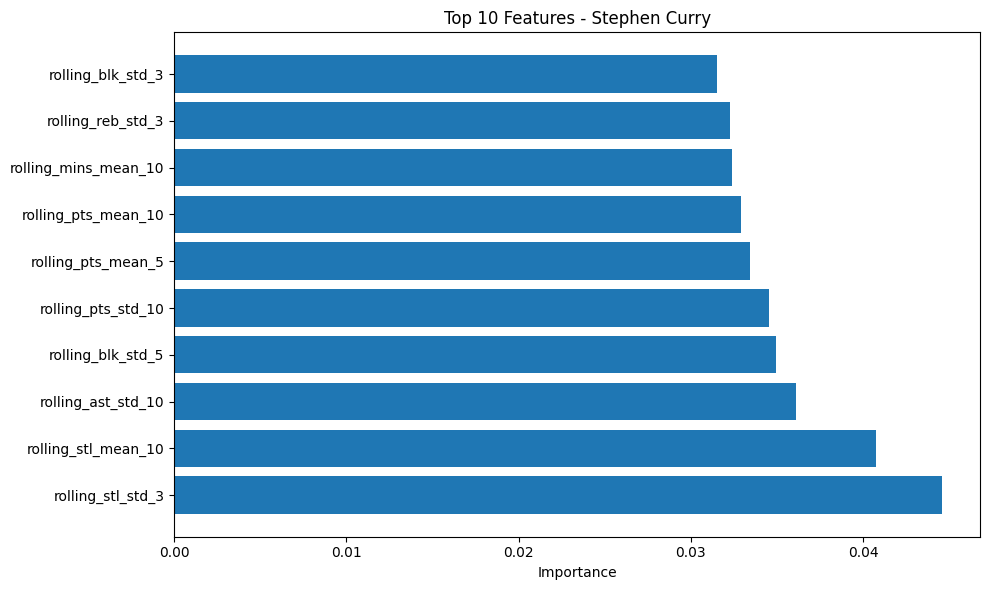

In [37]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': feature_cols_no_target,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"=== Top 10 Features ===")
print(importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance.head(10)['feature'], importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title(f'Top 10 Features - {test_player["longName"]}')
plt.tight_layout()
plt.show()

## 12. Validation Summary

In [26]:
print("\n" + "="*60)
print("PHASE 1 VALIDATION SUMMARY")
print("="*60)

print(f"\n[OK] Data Loading")
print(f"  - Test slate: {TEST_DATE}")
print(f"  - Training samples: {len(training_clean)}")
print(f"  - No temporal leakage verified")

print(f"\n[OK] Feature Engineering")
print(f"  - Config: {FEATURE_CONFIG}")
print(f"  - Features generated: {len(feature_cols_no_target)}")
print(f"  - Null handling: {len(training_features) - len(training_clean)} rows dropped")

print(f"\n[OK] Model Training & Prediction")
print(f"  - Player: {test_player['longName']}")
print(f"  - Actual: {y_test.values[0]:.2f} FPts")
print(f"  - Predicted: {y_pred[0]:.2f} FPts")
print(f"  - MAPE: {mape:.2f}%")

print(f"\n[OK] Ready for Phase 2: Full Slate Prediction")
print("="*60)


PHASE 1 VALIDATION SUMMARY

[OK] Data Loading
  - Test slate: 20250205
  - Training samples: 113
  - No temporal leakage verified

[OK] Feature Engineering
  - Config: base_features
  - Features generated: 42
  - Null handling: 2 rows dropped

[OK] Model Training & Prediction
  - Player: Stephen Curry
  - Actual: 47.25 FPts
  - Predicted: 45.40 FPts
  - MAPE: 3.91%

[OK] Ready for Phase 2: Full Slate Prediction
